# Testing out ERA5 on Casper

Run this in NPL 2025a, which loads useful packages.

In [2]:
# import necessary packages: numpy does numerical computations, matplotlib plots, and xarray is to handle massive arrays

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import dask

In [3]:
# information for ERA5 dataset.  See https://rda.ucar.edu/datasets/d633000/ 

pl = 'e5.oper.an.pl/'   # pressure level data
sl = 'e5.oper.an.sfc/'  # surface data
era5 = '/glade/campaign/collections/rda/data/d633000/'  # path to the era5 dataset

In [4]:
# dates to explore.  The star allows us to grab everything from the year
date='2024*'

In [5]:
# file header to get geopotential height files
code = 131
gzfile = era5 + pl + date + '/e5.oper.an.pl.128_'+ code + '_z.ll025sc.' + date + '.nc'

In [6]:
gzfile

'/glade/campaign/collections/rda/data/d633000/e5.oper.an.pl/2024*/e5.oper.an.pl.128_129_z.ll025sc.2024*.nc'

In [ ]:
# now get the actual data
# gz = xr.open_mfdataset(gzfile).  <- this would load the information about the files, but not the actual data

gz = xr.open_mfdataset(gzfile)

In [ ]:
gz

In [8]:
z=gz.Z / 9.8

In [9]:
z

<xarray.DataArray 'Z' (time: 8760, level: 37, latitude: 721, longitude: 1440)> Size: 1TB
dask.array<truediv, shape=(8760, 37, 721, 1440), dtype=float32, chunksize=(1, 37, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level      (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 70kB 1979-01-01 ... 1979-12-31T23:00:00

In [13]:
z.level

<xarray.DataArray 'level' (level: 37)> Size: 296B
array([   1.,    2.,    3.,    5.,    7.,   10.,   20.,   30.,   50.,   70.,
        100.,  125.,  150.,  175.,  200.,  225.,  250.,  300.,  350.,  400.,
        450.,  500.,  550.,  600.,  650.,  700.,  750.,  775.,  800.,  825.,
        850.,  875.,  900.,  925.,  950.,  975., 1000.])
Coordinates:
  * level    (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
Attributes:
    long_name:        pressure level
    short_name:       plev
    units:            hPa
    alternate_units:  millibar

In [9]:
# let's select levels 1000, 850, 500, and 200

z4levels=[1000,850,500,200]

z4lev = z.sel(level=z4levels)


In [10]:
z4lev

<xarray.DataArray 'Z' (time: 8760, level: 4, latitude: 721, longitude: 1440)> Size: 146GB
dask.array<getitem, shape=(8760, 4, 721, 1440), dtype=float32, chunksize=(1, 4, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level      (level) float64 32B 1e+03 850.0 500.0 200.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 70kB 2005-01-01 ... 2005-12-31T23:00:00

In [11]:
z500 = z.sel(level=500)
z500

<xarray.DataArray 'Z' (time: 8760, latitude: 721, longitude: 1440)> Size: 36GB
dask.array<getitem, shape=(8760, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level      float64 8B 500.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 70kB 2005-01-01 ... 2005-12-31T23:00:00

In [13]:
# take a daily mean by resampling and then taking the mean

z500daily=z500.resample(time='1D').mean('time')
z500daily

<xarray.DataArray 'Z' (time: 365, latitude: 721, longitude: 1440)> Size: 2GB
dask.array<transpose, shape=(365, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level      float64 8B 500.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31

In [18]:
# to actually force it to load and compute the data, add .compute

z500daily.compute()

<xarray.DataArray 'Z' (time: 365, latitude: 721, longitude: 1440)> Size: 2GB
array([[[5134.916 , 5134.916 , 5134.916 , ..., 5134.916 , 5134.916 ,
         5134.916 ],
        [5132.584 , 5132.5776, 5132.566 , ..., 5132.604 , 5132.5986,
         5132.5894],
        [5130.554 , 5130.537 , 5130.5234, ..., 5130.5923, 5130.5796,
         5130.565 ],
        ...,
        [5206.761 , 5206.7856, 5206.8145, ..., 5206.6826, 5206.709 ,
         5206.735 ],
        [5204.896 , 5204.912 , 5204.9224, ..., 5204.859 , 5204.8735,
         5204.8853],
        [5202.6733, 5202.6733, 5202.6733, ..., 5202.6733, 5202.6733,
         5202.6733]],

       [[5156.3286, 5156.3286, 5156.3286, ..., 5156.3286, 5156.3286,
         5156.3286],
        [5156.0156, 5155.9946, 5155.972 , ..., 5156.08  , 5156.061 ,
         5156.0386],
        [5155.555 , 5155.5137, 5155.471 , ..., 5155.6797, 5155.638 ,
         5155.596 ],
...
        [5132.1123, 5132.08  , 5132.054 , ..., 5132.2017, 5132.1763,
         5132.141 ],
        [5133.4995, 5133.4863, 5133.4727, ..., 5133.546 , 5133.528 ,
         5133.512 ],
        [5134.8906, 5134.8906, 5134.8906, ..., 5134.8906, 5134.8906,
         5134.8906]],

       [[5040.6675, 5040.6675, 5040.6675, ..., 5040.6675, 5040.6675,
         5040.6675],
        [5042.146 , 5042.15  , 5042.1533, ..., 5042.139 , 5042.1426,
         5042.1445],
        [5042.594 , 5042.5996, 5042.605 , ..., 5042.5747, 5042.579 ,
         5042.587 ],
        ...,
        [5145.0815, 5145.057 , 5145.026 , ..., 5145.1636, 5145.1367,
         5145.1113],
        [5143.436 , 5143.4243, 5143.4116, ..., 5143.48  , 5143.4673,
         5143.452 ],
        [5141.475 , 5141.475 , 5141.475 , ..., 5141.475 , 5141.475 ,
         5141.475 ]]], dtype=float32)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level      float64 8B 500.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31

In [14]:
zmz500daily=z500daily.mean('longitude').compute() # daily zonal mean at 500 mb 

In [15]:
# save the variable.  Here we save it to our current directory in home
#  scratch is here:  /glade/derecho/scratch/gerber/
#  home is here:  /glade/u/home/gerber/   

zmz500daily.to_netcdf(path='zmz500daily.nc')

In [5]:
zmz500daily=xr.open_mfdataset('zmz500daily.nc').to_array()

In [6]:
zmz500daily

<xarray.DataArray (variable: 1, time: 365, latitude: 721)> Size: 1MB
dask.array<stack, shape=(1, 365, 721), dtype=float32, chunksize=(1, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level     float64 8B ...
  * time      (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31
  * variable  (variable) object 8B 'Z'

In [9]:
# Let us now retrieve geopotential height data from 200, 850, and 1000 mb
z200 = z.sel(level = 200)
z850 = z.sel(level = 850)
z1000 = z.sel(level = 1000)

In [10]:
# Time means for these levels
z200daily = z200.resample(time='1D').mean('time')
z850daily = z850.resample(time='1D').mean('time')
z1000daily = z1000.resample(time='1D').mean('time')

In [14]:
# Compute the zonal means from the time means in parallel
zmz200d = z200daily.mean('longitude')
zmz850d = z850daily.mean('longitude')
zmz1000d = z1000daily.mean('longitude')

zmz200daily, zmz850daily, zmz1000daily = dask.compute(zmz200d, zmz850d, zmz1000d)

In [15]:
# Now save these as netCDF files
zmz200daily.to_netcdf(path='zmz200daily.nc')
zmz850daily.to_netcdf(path='zmz850daily.nc')
zmz1000daily.to_netcdf(path='zmz1000daily.nc')

In [7]:
zmz200daily = xr.open_mfdataset('zmz200daily.nc').to_array()
zmz200daily

<xarray.DataArray (variable: 1, time: 365, latitude: 721)> Size: 1MB
dask.array<stack, shape=(1, 365, 721), dtype=float32, chunksize=(1, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level     float64 8B ...
  * time      (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31
  * variable  (variable) object 8B 'Z'

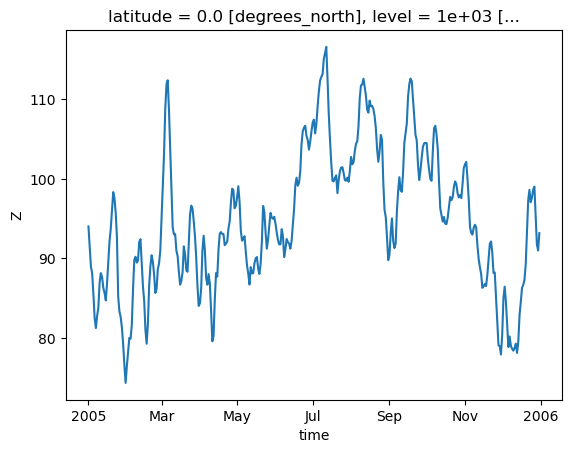

In [42]:
zmz1000daily.sel(latitude = 0).plot()


In [1]:
zmz850daily.plot()


NameError: name 'zmz850daily' is not defined

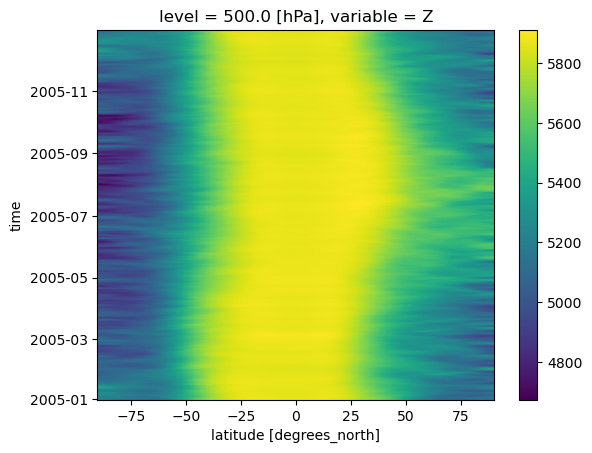

In [7]:
zmz500daily.plot()


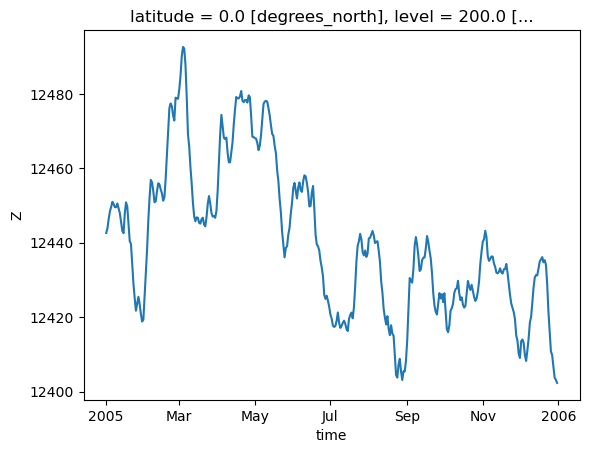

In [45]:
zmz200daily.sel(latitude = 0).plot()

In [14]:
folder_path = 'Z_zonal_means/'

In [15]:
zmzdaily1979 = xr.open_mfdataset(folder_path + 'zmzdaily1979.nc').to_array()

In [16]:
zmzdaily1979


<xarray.DataArray (variable: 1, time: 365, level: 37, latitude: 721)> Size: 39MB
dask.array<stack, shape=(1, 365, 37, 721), dtype=float32, chunksize=(1, 365, 37, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 3kB 1979-01-01 1979-01-02 ... 1979-12-31
  * variable  (variable) object 8B 'Z'

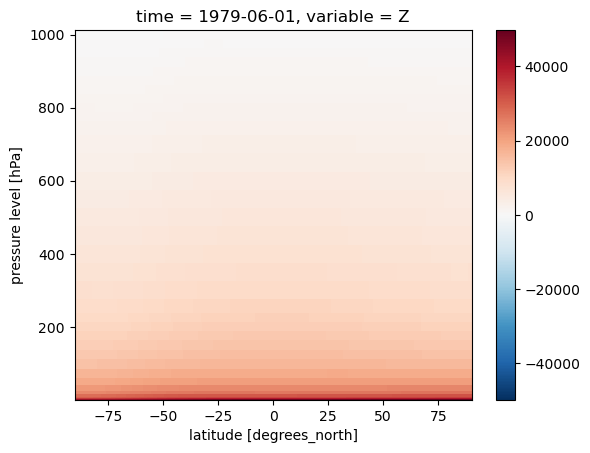

In [17]:
zmzdaily1979.sel(time = "1979-06-01").plot()

In [2]:
zmzdaily1980 = xr.open_mfdataset('Z_zonal_means/zmzdaily1982.nc').to_array()

In [3]:
zmzdaily1980

<xarray.DataArray (variable: 1, level: 37, time: 365, latitude: 721)> Size: 39MB
dask.array<stack, shape=(1, 37, 365, 721), dtype=float32, chunksize=(1, 37, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 3kB 1982-01-01 1982-01-02 ... 1982-12-31
  * variable  (variable) object 8B 'Z'

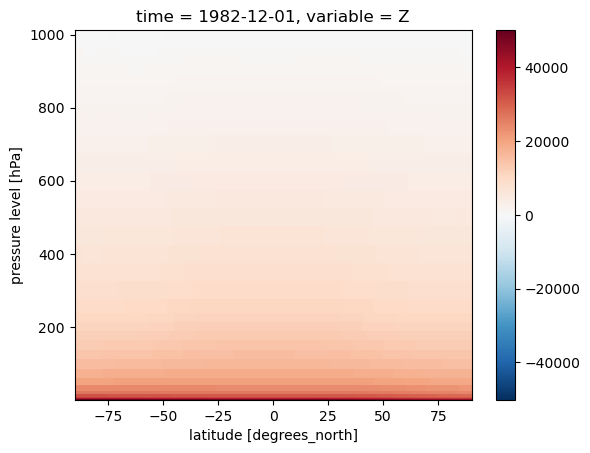

In [6]:
zmzdaily1980.sel(time = '1982-12-01').plot()

In [24]:
# coordinates

time = z.time.values  # adding the .values turns into a standard array.  otherwise it is an xarray structure

lat = z.latitude.values

lon = z.longitude.values

plev = z.level.values

In [11]:
# selecting date.  There are two options.  sel (preferred) and isel (not recommended)

# isel treats it like an array.  time = 1 means the first time (first hour on 1 of January).  level = 20 means the 20th level

z.isel(time = 1, level = 20)


<xarray.DataArray 'Z' (latitude: 721, longitude: 1440)> Size: 4MB
dask.array<getitem, shape=(721, 1440), dtype=float32, chunksize=(721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level      float64 8B 450.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time       datetime64[ns] 8B 2005-01-01T01:00:00

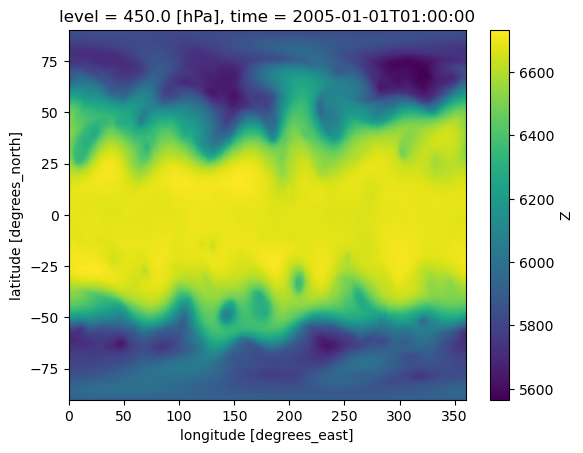

In [11]:
# plot the data

z.isel(time = 1, level = 20).plot()

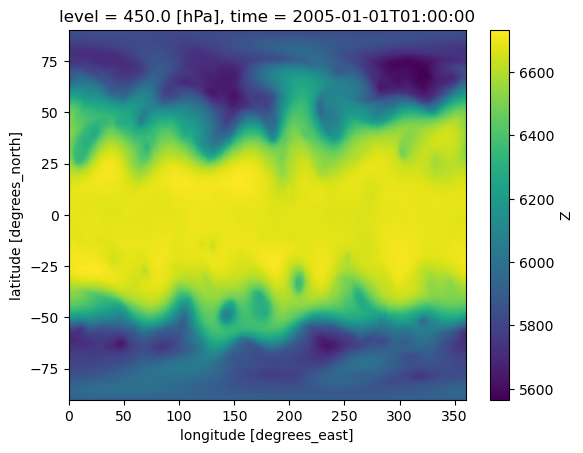

In [12]:
# now we will use sel.  Here you ask it to find the time / location you ask for

z.sel(time = time[1], level = plev[20]).plot()



In [13]:
plev[20]

450.0

In [14]:
time[1]

numpy.datetime64('2005-01-01T01:00:00.000000000')

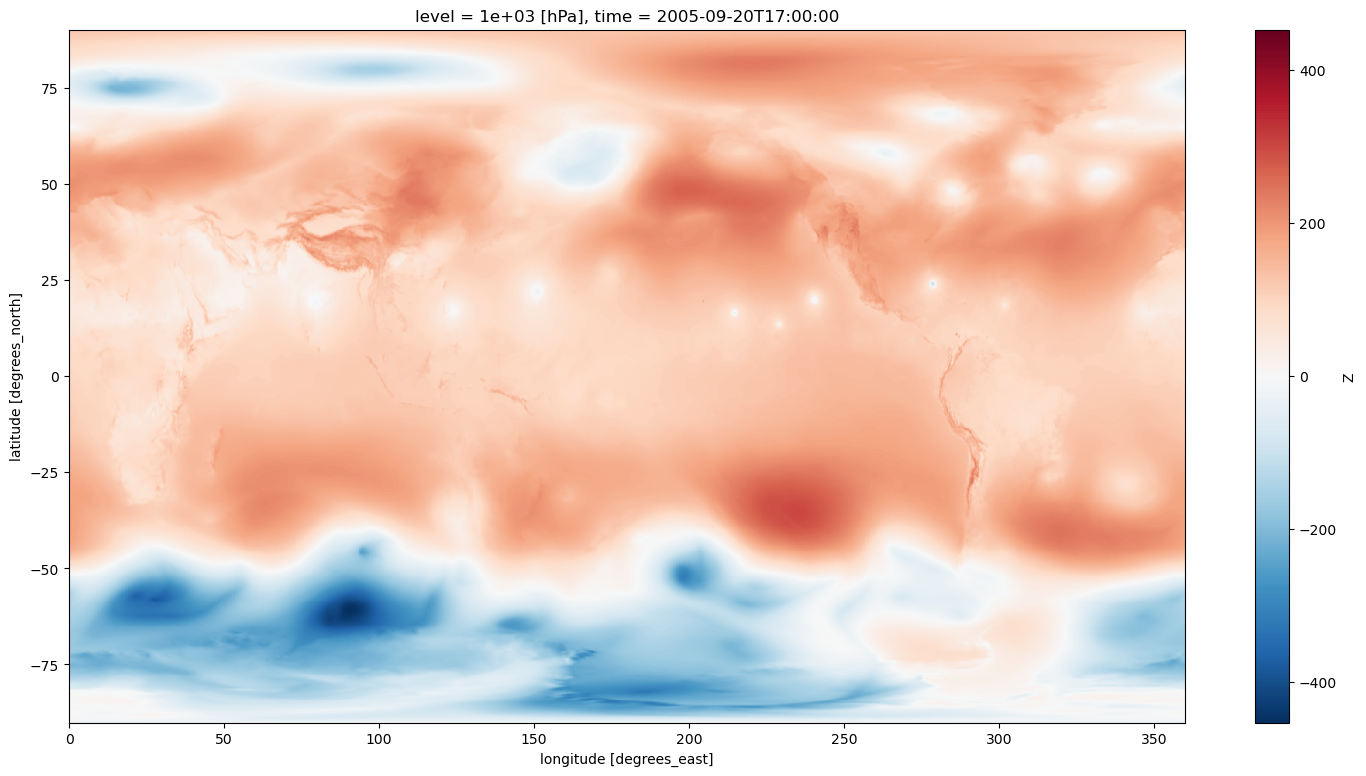

In [26]:
z.sel(time = '2005-09-20T17:00:00.000000000', level = plev[36]).plot(figsize=(18,9))


In [16]:
plev[36]

1000.0

In [20]:
# to take a mean of the data, use the .mean operation.  Here we take the zonal mean (over longitude)

zmz = z.mean('longitude')

In [21]:
zmz

<xarray.DataArray 'Z' (time: 8760, level: 37, latitude: 721)> Size: 935MB
dask.array<mean_agg-aggregate, shape=(8760, 37, 721), dtype=float32, chunksize=(1, 37, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 70kB 2005-01-01 ... 2005-12-31T23:00:00

In [22]:
# take the time mean

tmzmz = zmz.mean('time')

In [ ]:
tmzmz.plot()

In [ ]:
tmzmz